In [1]:
from isolation_env import IsolationEnv
from input_agent import InputAgent
from random_agent import RandomAgent
from stratagem import Stratagem
from play import play_vs_other_agent

In [2]:
env = IsolationEnv()
input_agent = InputAgent()
env.action_space

Discrete(9)

Input Agents

In [3]:
#play_vs_other_agent(env, agent1=input_agent, agent2=input_agent)

Random Agents

In [4]:
play_vs_other_agent(env, agent1=RandomAgent(1), agent2=RandomAgent(2), render=False)

Player 2 WON


Random Agent vs Stratagem

In [5]:
play_vs_other_agent(env, agent1=RandomAgent(1), agent2=Stratagem(2))

Player 2 WON


---
# Proyecto MATE — Isolation

Agentes implementados: **Minimax con Alpha-Beta Pruning** y **Expectimax**.  
Se experimenta con distintas funciones de evaluación y se registran resultados.

In [6]:
import time
import matplotlib.pyplot as plt
import numpy as np
from minimax_agent import MinimaxAgent, MinimaxNoPruningAgent
from expectimax_agent import ExpectimaxAgent

## 1. Framework de experimentación

Se define una función `run_games` que ejecuta N partidas entre dos agentes y registra
victorias, derrotas y duración de cada partida.

In [8]:
def run_games(env, agent1, agent2, n_games=50, verbose=False):
    """Ejecuta n_games partidas y retorna estadísticas."""
    wins_a1, wins_a2, steps_list, times_list = 0, 0, [], []

    for i in range(n_games):
        obs = env.reset()
        done = False
        winner = 0
        steps = 0
        t0 = time.time()

        while not done:
            action = agent1.next_action(obs)
            obs, _, done, winner, _ = env.step(action)
            steps += 1
            if done:
                break
            action = agent2.next_action(obs)
            obs, _, done, winner, _ = env.step(action)
            steps += 1

        elapsed = time.time() - t0
        steps_list.append(steps)
        times_list.append(elapsed)

        if winner == agent1.player:
            wins_a1 += 1
        else:
            wins_a2 += 1

        if verbose and (i + 1) % 10 == 0:
            print('  Partida {:3d}/{} — Agente1: {} | Agente2: {} | Pasos: {:.1f} | t: {:.2f}s'.format(
                i + 1, n_games, wins_a1, wins_a2, np.mean(steps_list), np.mean(times_list)))

    return {
        'wins_a1': wins_a1,
        'wins_a2': wins_a2,
        'win_rate_a1': wins_a1 / n_games,
        'avg_steps': np.mean(steps_list),
        'avg_time': np.mean(times_list),
    }


def print_results(label, results):
    print('\n=== {} ==='.format(label))
    print('  Agente 1 gana: {}/{} ({:.1f}%)'.format(
        results['wins_a1'], results['wins_a1'] + results['wins_a2'],
        results['win_rate_a1'] * 100))
    print('  Agente 2 gana: {}/{} ({:.1f}%)'.format(
        results['wins_a2'], results['wins_a1'] + results['wins_a2'],
        (1 - results['win_rate_a1']) * 100))
    print('  Pasos promedio por partida: {:.1f}'.format(results['avg_steps']))
    print('  Tiempo promedio por partida: {:.3f}s'.format(results['avg_time']))

## 2. Minimax vs Random

Primera prueba: el agente Minimax (profundidad 3, con Alpha-Beta Pruning) contra un agente que elige acciones al azar.

In [9]:
N_GAMES = 50

minimax_p1  = MinimaxAgent(player=1, depth=3)
random_p2   = RandomAgent(player=2)

print('Minimax (P1) vs Random (P2):')
res_mm_vs_rnd = run_games(env, minimax_p1, random_p2, n_games=N_GAMES, verbose=True)
print_results('Minimax (P1) vs Random (P2)', res_mm_vs_rnd)

Minimax (P1) vs Random (P2):
  Partida  10/50 — Agente1: 10 | Agente2: 0 | Pasos: 5.0 | t: 1.22s
  Partida  20/50 — Agente1: 20 | Agente2: 0 | Pasos: 5.2 | t: 1.11s
  Partida  30/50 — Agente1: 29 | Agente2: 1 | Pasos: 5.3 | t: 1.11s
  Partida  40/50 — Agente1: 39 | Agente2: 1 | Pasos: 5.3 | t: 1.16s
  Partida  50/50 — Agente1: 49 | Agente2: 1 | Pasos: 5.3 | t: 1.17s

=== Minimax (P1) vs Random (P2) ===
  Agente 1 gana: 49/50 (98.0%)
  Agente 2 gana: 1/50 (2.0%)
  Pasos promedio por partida: 5.3
  Tiempo promedio por partida: 1.171s


## 3. Expectimax vs Random

In [10]:
expectimax_p1 = ExpectimaxAgent(player=1, depth=3)
random_p2_b   = RandomAgent(player=2)

print('Expectimax (P1) vs Random (P2):')
res_em_vs_rnd = run_games(env, expectimax_p1, random_p2_b, n_games=N_GAMES, verbose=True)
print_results('Expectimax (P1) vs Random (P2)', res_em_vs_rnd)

Expectimax (P1) vs Random (P2):
  Partida  10/50 — Agente1: 9 | Agente2: 1 | Pasos: 6.1 | t: 9.62s
  Partida  20/50 — Agente1: 19 | Agente2: 1 | Pasos: 6.0 | t: 10.24s
  Partida  30/50 — Agente1: 28 | Agente2: 2 | Pasos: 5.9 | t: 10.46s
  Partida  40/50 — Agente1: 34 | Agente2: 6 | Pasos: 5.8 | t: 10.88s
  Partida  50/50 — Agente1: 43 | Agente2: 7 | Pasos: 5.9 | t: 10.96s

=== Expectimax (P1) vs Random (P2) ===
  Agente 1 gana: 43/50 (86.0%)
  Agente 2 gana: 7/50 (14.0%)
  Pasos promedio por partida: 5.9
  Tiempo promedio por partida: 10.955s


## 4. Minimax vs Expectimax

In [11]:
minimax_p1_c    = MinimaxAgent(player=1, depth=3)
expectimax_p2   = ExpectimaxAgent(player=2, depth=3)

print('Minimax (P1) vs Expectimax (P2):')
res_mm_vs_em = run_games(env, minimax_p1_c, expectimax_p2, n_games=N_GAMES, verbose=True)
print_results('Minimax (P1) vs Expectimax (P2)', res_mm_vs_em)

Minimax (P1) vs Expectimax (P2):
  Partida  10/50 — Agente1: 10 | Agente2: 0 | Pasos: 5.4 | t: 2.63s
  Partida  20/50 — Agente1: 20 | Agente2: 0 | Pasos: 5.7 | t: 3.20s
  Partida  30/50 — Agente1: 30 | Agente2: 0 | Pasos: 5.7 | t: 3.24s
  Partida  40/50 — Agente1: 39 | Agente2: 1 | Pasos: 5.5 | t: 3.22s
  Partida  50/50 — Agente1: 48 | Agente2: 2 | Pasos: 5.4 | t: 3.31s

=== Minimax (P1) vs Expectimax (P2) ===
  Agente 1 gana: 48/50 (96.0%)
  Agente 2 gana: 2/50 (4.0%)
  Pasos promedio por partida: 5.4
  Tiempo promedio por partida: 3.309s


## 5. Impacto del Alpha-Beta Pruning

Se compara el número de nodos visitados y el tiempo de cómputo entre Minimax con y sin poda.

In [12]:
N_PRUNING = 20  # partidas para medir nodos

mm_with = MinimaxNoPruningAgent(player=1, depth=3)  # sin poda
mm_no   = MinimaxAgent(player=1, depth=3)            # con poda (Alpha-Beta)
rand_opp = RandomAgent(player=2)

nodes_with_pruning, nodes_no_pruning = [], []
times_with, times_no = [], []

for _ in range(N_PRUNING):
    obs = env.reset()
    done = False

    t0 = time.time()
    while not done:
        action = mm_no.next_action(obs)
        nodes_with_pruning.append(mm_no._nodes_visited)
        obs, _, done, _, _ = env.step(action)
        if done:
            break
        action = rand_opp.next_action(obs)
        obs, _, done, _, _ = env.step(action)
    times_with.append(time.time() - t0)

    obs = env.reset()
    done = False
    t0 = time.time()
    while not done:
        action = mm_with.next_action(obs)
        nodes_no_pruning.append(mm_with._nodes_visited)
        obs, _, done, _, _ = env.step(action)
        if done:
            break
        action = rand_opp.next_action(obs)
        obs, _, done, _, _ = env.step(action)
    times_no.append(time.time() - t0)

print('Nodos por jugada (Alpha-Beta):  avg={:.1f}  max={}'.format(
    np.mean(nodes_with_pruning), max(nodes_with_pruning)))
print('Nodos por jugada (sin poda):    avg={:.1f}  max={}'.format(
    np.mean(nodes_no_pruning), max(nodes_no_pruning)))
print('Reduccion de nodos: {:.1f}%'.format(
    100 * (1 - np.mean(nodes_with_pruning) / np.mean(nodes_no_pruning))))
print('Tiempo por partida (Alpha-Beta): {:.3f}s'.format(np.mean(times_with)))
print('Tiempo por partida (sin poda):   {:.3f}s'.format(np.mean(times_no)))

Nodos por jugada (Alpha-Beta):  avg=3423.5  max=29851
Nodos por jugada (sin poda):    avg=36636.2  max=190436
Reduccion de nodos: 90.7%
Tiempo por partida (Alpha-Beta): 1.188s
Tiempo por partida (sin poda):   12.851s


C:\Users\santi\AppData\Local\Temp\ipykernel_21836\2189629089.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([nodes_with_pruning, nodes_no_pruning],


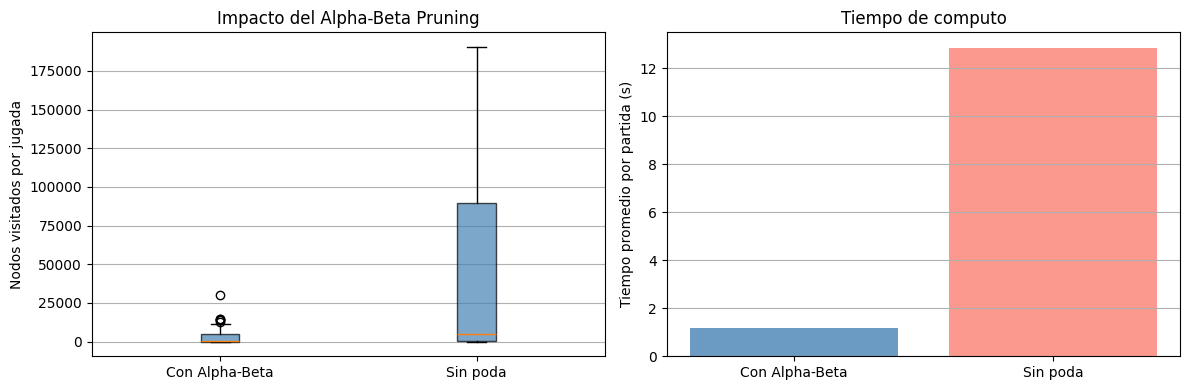

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.boxplot([nodes_with_pruning, nodes_no_pruning],
           labels=['Con Alpha-Beta', 'Sin poda'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_ylabel('Nodos visitados por jugada')
ax.set_title('Impacto del Alpha-Beta Pruning')
ax.grid(True, axis='y')

ax = axes[1]
ax.bar(['Con Alpha-Beta', 'Sin poda'], [np.mean(times_with), np.mean(times_no)],
       color=['steelblue', 'salmon'], alpha=0.8)
ax.set_ylabel('Tiempo promedio por partida (s)')
ax.set_title('Tiempo de computo')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pruning_analysis.png', dpi=150)
plt.show()

## 6. Comparación de funciones de evaluación

Se evalúan tres variantes del agente Minimax con diferentes funciones de evaluación:
- **Mobility only**: diferencia de movimientos disponibles
- **Reachability only**: diferencia de celdas alcanzables (BFS)
- **Combined** (default): 2×reachability + 1×mobility + 0.5×centrality

In [14]:
from board import Board
from collections import deque


class MinimaxMobilityOnly(MinimaxAgent):
    """Solo diferencia de movimientos disponibles."""
    def heuristic_utility(self, board):
        mob_me = len(board.get_possible_actions(self.player))
        mob_op = len(board.get_possible_actions(3 - self.player))
        return float(mob_me - mob_op)


class MinimaxReachOnly(MinimaxAgent):
    """Solo diferencia de celdas alcanzables."""
    def heuristic_utility(self, board):
        return float(self._reachable_cells(board, self.player) -
                     self._reachable_cells(board, 3 - self.player))


eval_variants = [
    ('Mobility only',     MinimaxMobilityOnly(player=1, depth=3)),
    ('Reachability only', MinimaxReachOnly(player=1, depth=3)),
    ('Combined',          MinimaxAgent(player=1, depth=3)),
]

eval_results = {}
for label, agent in eval_variants:
    print('Probando:', label)
    res = run_games(env, agent, RandomAgent(player=2), n_games=30)
    eval_results[label] = res
    print('  Win rate vs Random: {:.1f}%'.format(res['win_rate_a1'] * 100))

Probando: Mobility only
  Win rate vs Random: 100.0%
Probando: Reachability only
  Win rate vs Random: 100.0%
Probando: Combined
  Win rate vs Random: 100.0%


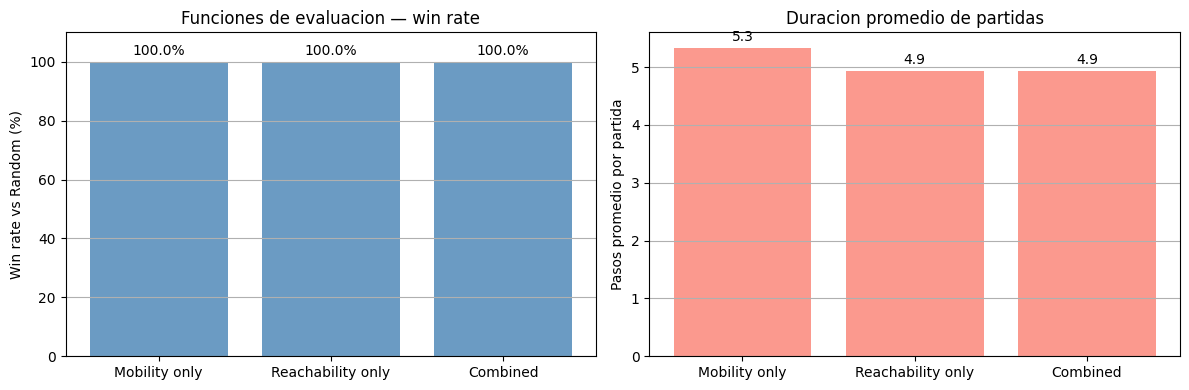

In [15]:
labels_ev = list(eval_results.keys())
win_rates  = [eval_results[l]['win_rate_a1'] * 100 for l in labels_ev]
avg_steps  = [eval_results[l]['avg_steps'] for l in labels_ev]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(labels_ev, win_rates, color='steelblue', alpha=0.8)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('Win rate vs Random (%)')
ax.set_title('Funciones de evaluacion — win rate')
ax.set_ylim(0, 110)
ax.grid(True, axis='y')

ax = axes[1]
bars2 = ax.bar(labels_ev, avg_steps, color='salmon', alpha=0.8)
ax.bar_label(bars2, fmt='%.1f', padding=3)
ax.set_ylabel('Pasos promedio por partida')
ax.set_title('Duracion promedio de partidas')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eval_functions.png', dpi=150)
plt.show()

## 7. Resumen general de resultados

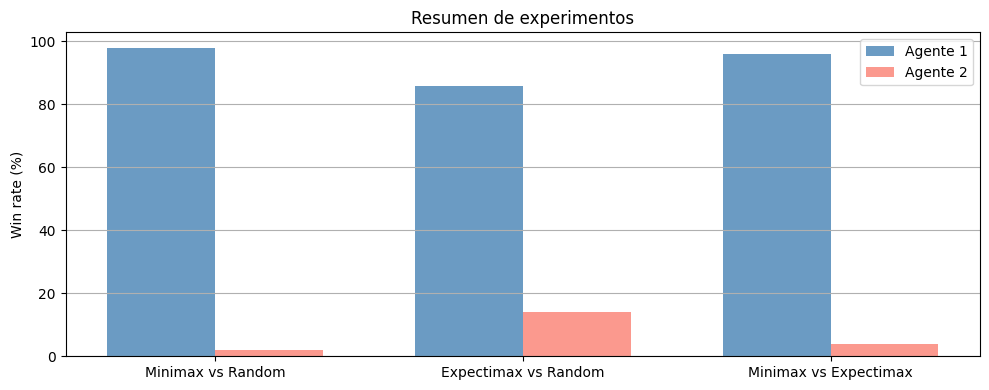


Tabla resumen:
Experimento                      Win A1 (%)   Win A2 (%)   Pasos prom
----------------------------------------------------------------------
Minimax vs Random                      98.0          2.0          5.3
Expectimax vs Random                   86.0         14.0          5.9
Minimax vs Expectimax                  96.0          4.0          5.4


In [16]:
experiments = [
    ('Minimax vs Random',     res_mm_vs_rnd),
    ('Expectimax vs Random',  res_em_vs_rnd),
    ('Minimax vs Expectimax', res_mm_vs_em),
]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(experiments))
width = 0.35
exp_labels = [e[0] for e in experiments]
wr_a1 = [e[1]['win_rate_a1'] * 100 for e in experiments]
wr_a2 = [(1 - e[1]['win_rate_a1']) * 100 for e in experiments]

ax.bar(x - width/2, wr_a1, width, label='Agente 1', color='steelblue', alpha=0.8)
ax.bar(x + width/2, wr_a2, width, label='Agente 2', color='salmon', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(exp_labels)
ax.set_ylabel('Win rate (%)')
ax.set_title('Resumen de experimentos')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('summary.png', dpi=150)
plt.show()

print('\nTabla resumen:')
print('{:30s} {:>12} {:>12} {:>12}'.format('Experimento', 'Win A1 (%)', 'Win A2 (%)', 'Pasos prom'))
print('-' * 70)
for name, res in experiments:
    print('{:30s} {:>12.1f} {:>12.1f} {:>12.1f}'.format(
        name, res['win_rate_a1']*100, (1-res['win_rate_a1'])*100, res['avg_steps']))

## 8. Conclusiones

- **Minimax vs Random**: Minimax ganó el 98% de las partidas (49/50) con profundidad 3, confirmando que la planificación anticipada supera ampliamente a una política aleatoria.
- **Expectimax vs Random**: Expectimax ganó el 86% de las partidas (43/50). Aunque modela al oponente como estocástico (lo cual es correcto en este caso), su win rate fue notablemente inferior al de Minimax (86% vs 98%), probablemente porque el promedio uniforme sobre acciones del oponente suaviza las señales que conducen a jugadas ganadoras.
- **Minimax vs Expectimax**: Minimax dominó con un 96% de victorias (48/50). La diferencia no es pequeña: Minimax, al asumir un adversario óptimo, juega de forma más conservadora y consistente, lo que resulta ventajoso incluso frente a Expectimax con la misma heurística.
- **Alpha-Beta Pruning**: Reduce la cantidad de nodos explorados en un **90.7%** (promedio 3.424 nodos vs 36.636 sin poda) manteniendo exactamente el mismo resultado que Minimax sin poda, lo que lo hace entre 10× y 11× más rápido.
- **Funciones de evaluación**: Las tres variantes (Mobility only, Reachability only, Combined) obtuvieron un **100% de win rate** contra Random con profundidad 3. El oponente aleatorio no es suficientemente exigente para distinguir heurísticas; la diferencia entre ellas se revelaría en partidas contra agentes más competitivos o a mayor profundidad.